In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [199]:
df=pd.read_csv(r"netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8800 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [201]:
df.drop_duplicates(inplace=True)

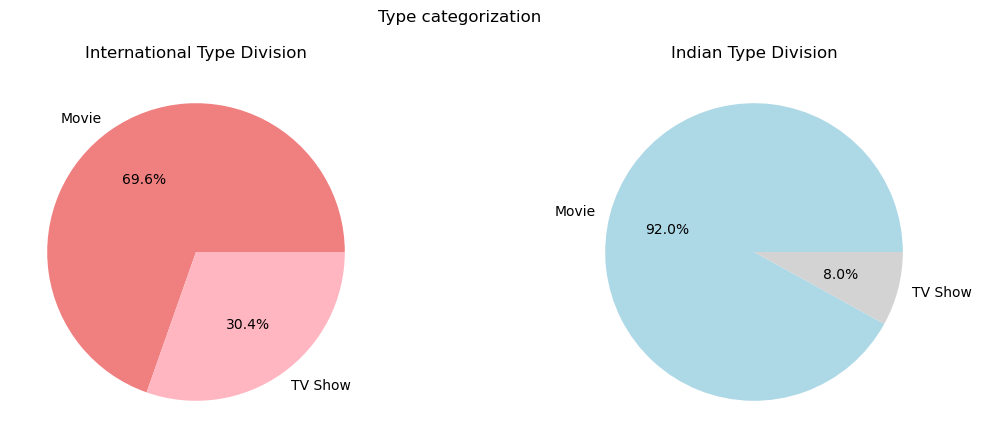

In [202]:
a=df["type"]
a=a.dropna()
b=a.value_counts()
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.pie(b,labels=b.index,colors=["lightcoral","lightpink"],autopct="%1.1f%%",)
plt.title("International Type Division")
a=df.loc[df["country"].str.contains("India",na=False)]["type"]
b=a.value_counts()
plt.subplot(1,2,2)
plt.pie(b,labels=b.index,colors=["lightblue","lightgrey"],autopct="%1.1f%%",)
plt.title("Indian Type Division")
plt.suptitle("Type categorization")
plt.subplots_adjust(wspace=0.5)
plt.savefig("Type Categorization.png",dpi=300,bbox_inches="tight")
plt.show()

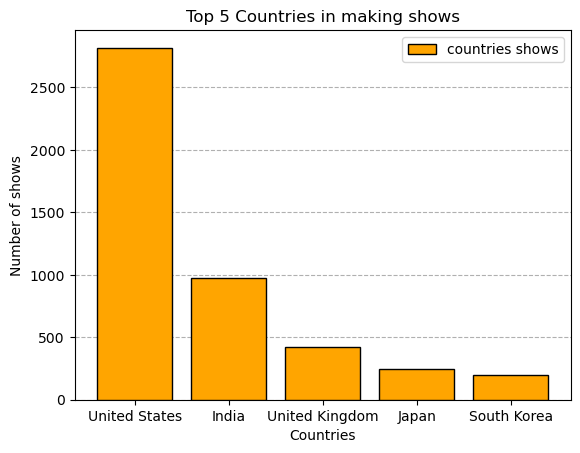

In [203]:
a=df['country']
a.dropna(inplace=True)
c=a.value_counts()
c=c.head()
plt.bar(c.index,c,color="orange",width=0.8,edgecolor="black",zorder=3,label="countries shows")
plt.grid(axis="y",linestyle="--")
plt.title("Top 5 Countries in making shows")
plt.xlabel("Countries")
plt.ylabel("Number of shows")
plt.legend(loc="upper right")
plt.savefig("Countries Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

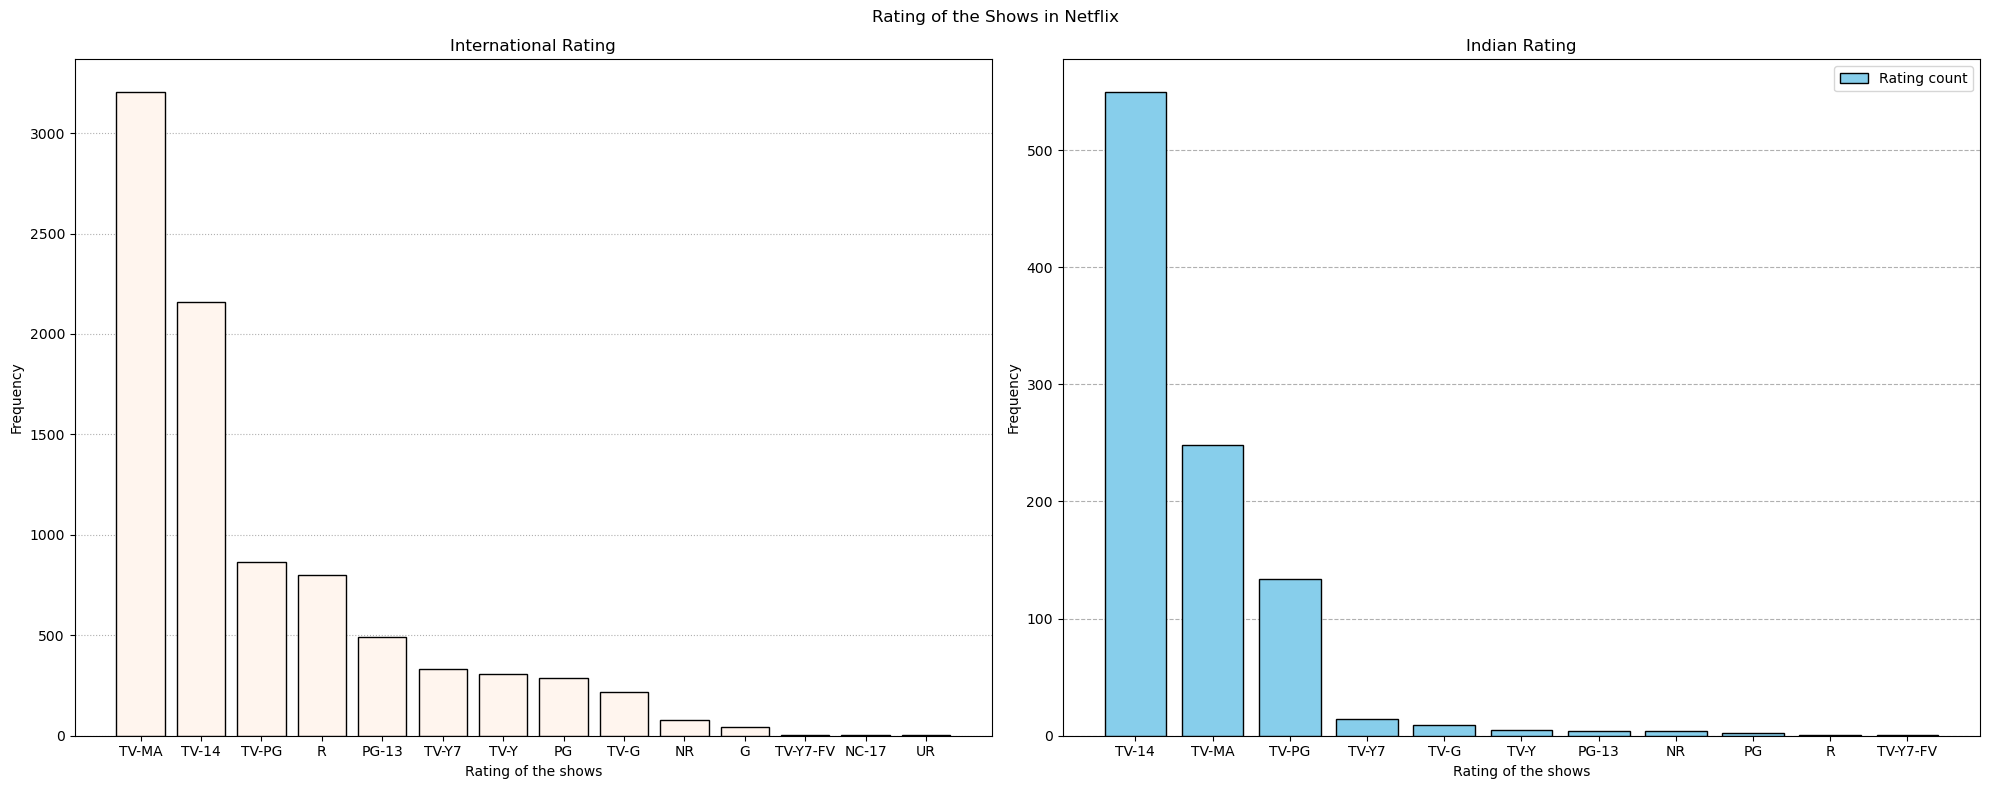

In [204]:
#International and Indian rating
a=df["rating"]
a=a.dropna()
b=a.value_counts()
plt.figure(figsize=(20,8),layout="tight")
plt.subplot(1,2,1)
plt.bar(b.index,b,color="seashell",edgecolor="black",zorder=3,label="Rating count",width=0.8)
plt.xlabel("Rating of the shows")
plt.ylabel("Frequency")
plt.title("International Rating")
plt.grid(axis="y",linestyle=":")
df2=df.loc[df["country"]=="India"]
b=df2['rating']
b=b.dropna()
c=b.value_counts()
plt.subplot(1,2,2)
plt.bar(c.index,c,color="skyblue",edgecolor="black",zorder=3,label="Rating count",width=0.8)
plt.xlabel("Rating of the shows",)
plt.ylabel("Frequency")
plt.title("Indian Rating")
plt.legend(loc="upper right")
plt.grid(axis="y",linestyle="--")
plt.suptitle("Rating of the Shows in Netflix")
plt.subplots_adjust(wspace=0.5)
plt.savefig("Rating shows.png",dpi=300,bbox_inches="tight")
plt.show()

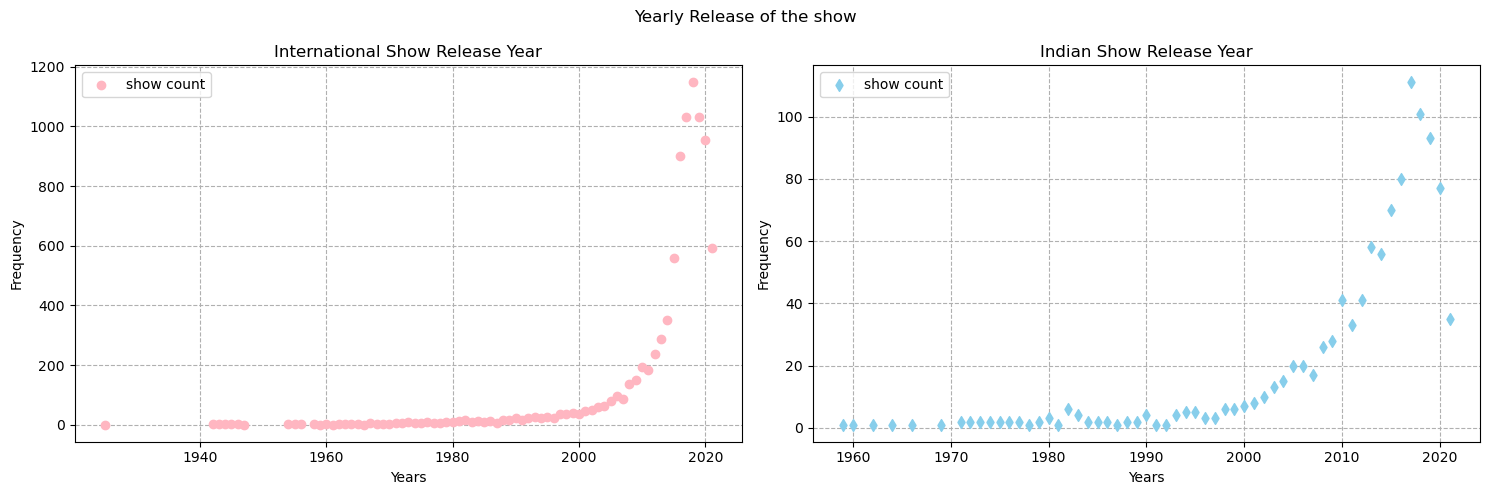

In [205]:
#release year
a=df.copy()
a=a.dropna(subset=["release_year"])
b=a["release_year"].value_counts()
plt.figure(figsize=(15,5),layout="tight")
plt.subplot(1,2,1)
plt.scatter(b.index,b,color="lightpink",label="show count",marker="o",zorder=3)
plt.legend(loc="upper left")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.title("International Show Release Year")
plt.grid(linestyle="--")
a=df[df["country"].str.contains("India", na=False)]["release_year"].value_counts()
plt.subplot(1,2,2)
plt.scatter(a.index,a,color="skyblue",label="show count",marker="d",zorder=3)
plt.legend(loc="upper left")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.title("Indian Show Release Year")
plt.grid(linestyle="--")
plt.suptitle("Yearly Release of the show")
plt.subplots_adjust(wspace=1.0)
plt.tight_layout()
plt.savefig("Release year.png",dpi=300,bbox_inches="tight")
plt.show()

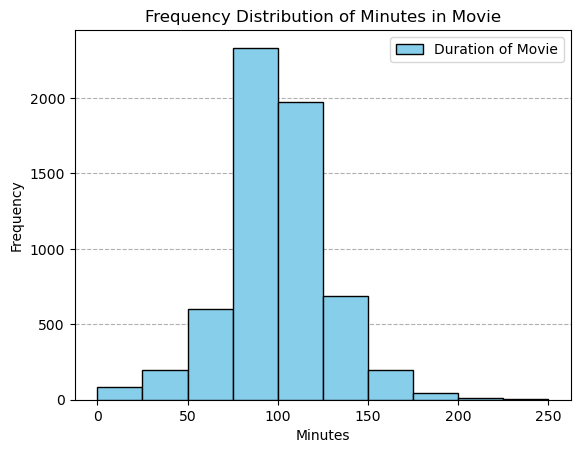

In [206]:
#Movie duration:
def duration(s):
    temp=0
    for i in s:
        if i.isdigit():
            b=int(i)
            temp=temp*10+b
        else:
            break
    return temp
list1=[]
for i in df.loc[df["type"]=="Movie"]["duration"]:
    a=duration(i)
    list1.append(a)
plt.hist(list1,bins=10,range=(0,250),color="skyblue",edgecolor="black",label="Duration of Movie",zorder=3)
plt.legend(loc="upper right")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.title("Frequency Distribution of Minutes in Movie")
plt.grid(axis="y",linestyle="--")
plt.savefig("Minutes Frequency.png",dpi=300,bbox_inches="tight")
plt.show()

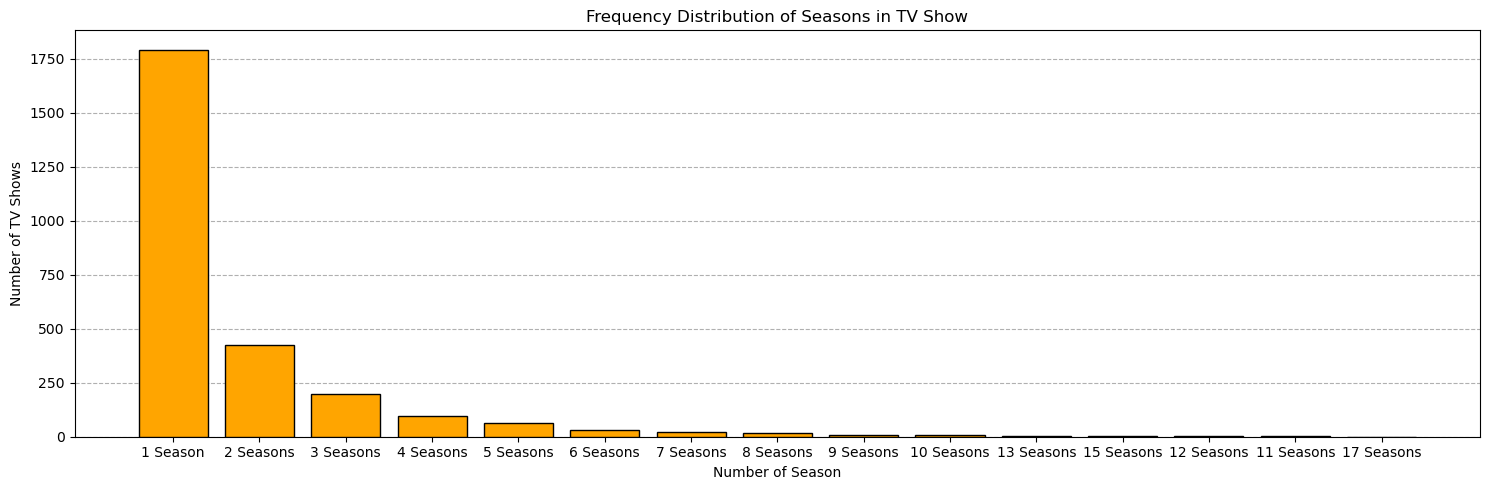

In [207]:
a=df.loc[df["type"]=="TV Show"]
a=a.dropna(subset=["duration"])
b=a["duration"].value_counts()
plt.figure(figsize=(15,5))
plt.bar(b.index,b,color="orange",edgecolor="black",zorder=3)
plt.xlabel("Number of Season")
plt.ylabel("Number of TV Shows")
plt.title("Frequency Distribution of Seasons in TV Show")
plt.grid(axis="y",linestyle="--")
plt.tight_layout()
plt.savefig("Seasons Distribution.png",dpi=300,bbox_inches="tight")
plt.show()